# <span style="color:#0097b2">0. Data</span>
[Back to TOC](#toc)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Libraries Importation</h3>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans, AgglomerativeClustering

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Data Importation</h3>

In [2]:
people = pd.read_csv("../data/cleaned_data/clustering_data_cleaned.csv", index_col = 'Loyalty#')

df_eng = pd.read_csv('../data/engagement_based_perspective_clusters.csv', index_col='Loyalty#')

df_beh = pd.read_csv('../data/behvioral_segment_data.csv', index_col='Loyalty#')

df_val = pd.read_csv('../data/value_based_perspective_clusters.csv', index_col='Loyalty#')

def get_rsq(df, feats, label_col):
    """
    Calculate the R-squared value for a given DataFrame and features.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame containing the data.
    feats (list): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing the labels or cluster assignments.
    
    Returns:
    float: The R-squared value, representing the proportion of variance explained by the clustering.
    """
    df_sst_ = get_ss(df, feats)  # get total sum of squares
    df_ssw_ = get_ssw(df, feats, label_col)  # get ss within
    df_ssb_ = df_sst_ - df_ssw_  # get ss between
    # r2 = ssb/sst
    return (df_ssb_ / df_sst_)

def get_ss(df, feats):
    """
    Calculate the sum of squares (SS) for the given DataFrame.
    The sum of squares is computed as the sum of the variances of each column
    multiplied by the number of non-NA/null observations minus one.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame for which the sum of squares is to be calculated.
    feats (list of str): A list of feature column names to be used in the calculation.
    
    Returns:
    float: The sum of squares of the DataFrame.
    """
    df_ = df[feats]
    ss = np.sum(df_.var() * (df_.count() - 1))
    return ss

def get_ssw(df, feats, label_col):
    """
    Calculate the sum of squared within-cluster distances (SSW) for a given DataFrame.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame containing the data.
    feats (list of str): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing cluster labels.
    
    Returns:
    float: The sum of squared within-cluster distances (SSW).
    """
    feats_label = feats + [label_col]
    df_k = df[feats_label].groupby(by=label_col).apply(
        lambda col: get_ss(col, feats),
        include_groups=False
    )
    return df_k.sum()

def groupby_mean(data, variable, n_features=30):
    """
    Groups data and returns transposed mean of top features.
    Added 'numeric_only=True' to avoid errors with string columns.
    """
    grouped_data = data.groupby(variable).mean(numeric_only=True)
    
    result = grouped_data.iloc[:, :n_features].T
    return result

# <span style="color:#0097b2">1. Data Preparation & Label Extraction</span>
[Back to TOC](#toc)

In [3]:
df_merged = df_val.copy()

cols_to_add_beh = df_beh.columns.difference(df_merged.columns)
df_merged = df_merged.join(df_beh[cols_to_add_beh])

cols_to_add_eng = df_eng.columns.difference(df_merged.columns)
df_merged = df_merged.join(df_eng[cols_to_add_eng])

In [4]:
df_merged

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,TotalFlights,TotalDistance,...,seg_Jan_Feb_travelers,seg_No_Activity,seg_Active_Travelers,seg_Active_Travelers.1,seg_Dormant_Travelers,seg_Dormant_Travelers.1,seg_Low_Engagement,seg_Low_Engagement.1,seg_Non_Travelers,seg_Non_Travelers.1
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,0.0,0.0,...,0,0,0,0,0,0,0,0,1,1
100012,34148.0,5780.18,0,0,0.0,0,2019,2,0.0,0.0,...,0,0,0,0,0,0,0,0,1,1
100013,34148.0,5780.18,0,0,0.0,0,2017,9,0.0,0.0,...,0,0,0,0,0,0,0,0,1,1
100014,34148.0,5780.18,0,0,0.0,0,2020,11,0.0,0.0,...,0,0,0,0,0,0,0,0,1,1
100015,34148.0,5780.18,0,0,0.0,0,2020,4,0.0,0.0,...,0,0,0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,0.0,0.0,...,0,0,0,0,0,0,0,0,1,1
999996,34148.0,5780.18,0,0,0.0,0,2018,9,0.0,0.0,...,0,0,0,0,0,0,0,0,1,1
999997,34148.0,5780.18,0,0,0.0,0,2020,1,0.0,0.0,...,0,0,0,0,0,0,0,0,1,1


In [5]:
def decode_ohe_segments(df, prefix):
    seg_cols = [c for c in df.columns if c.startswith(prefix)]
    return df[seg_cols].idxmax(axis=1)

In [6]:
df_merged['Value_Label'] = decode_ohe_segments(
    df_val, prefix='seg_'
)

df_merged['Behavior_Label'] = decode_ohe_segments(
    df_beh, prefix='seg_'
)

df_merged['Engagement_Label'] = decode_ohe_segments(
    df_eng, prefix='seg_'
)

df_merged['Location_Label'] = decode_ohe_segments(
    df_val, prefix='Location_'
)

In [7]:
features_to_exclude = [c for c in df_merged.columns if c.startswith('seg_')]

metric_features = (
    df_merged
    .drop(columns=features_to_exclude)
    .select_dtypes(include='number')
    .columns
    .tolist()
)

In [8]:
df_centroids = df_merged.groupby(['Value_Label', 'Behavior_Label', 'Engagement_Label', 'Location_Label'])[metric_features].mean()
df_centroids

Income  \
Value_Label          Behavior_Label        Engagement_Label     Location_Label                 
seg_Core_Loyalists   seg_Active_Redeemers  seg_Active_Travelers Location__0     36467.166667   
                                                                Location__1     32556.773585   
                                                                Location__2     35434.261538   
                                                                Location__3     31775.600000   
                                                                Location__4     34258.803922   
...                                                                                      ...   
seg_Low_Value_Active seg_Holiday_travelers seg_Low_Engagement   Location__3      1778.509434   
                                                                Location__4      1750.267568   
                                                                Location__5      2584.676056   
                                                                Location__6      2913.000000   
                                                                Location__7         0.000000   

                                                                                Customer Lifetime Value  \
Value_Label          Behavior_Label        Engagement_Label     Location_Label                            
seg_Core_Loyalists   seg_Active_Redeemers  seg_Active_Travelers Location__0                10511.824167   
                                                                Location__1                 9712.113962   
                                                                Location__2                 9064.351231   
                                                                Location__3                10724.383500   
                                                                Location__4                 8233.630784   
...                                                                                                 ...   
seg_Low_Value_Active seg_Holiday_travelers seg_Low_Engagement   Location__3                 8100.739528   
                                                                Location__4                 7833.769703   
                                                                Location__5                 7371.415775   
                                                                Location__6                 7564.080000   
                                                                Location__7                 6689.503571   

                                                                                EnrollmentType  \
Value_Label          Behavior_Label        Engagement_Label     Location_Label                   
seg_Core_Loyalists   seg_Active_Redeemers  seg_Active_Travelers Location__0           0.083333   
                                                                Location__1           0.094340   
                                                                Location__2           0.200000   
                                                                Location__3           0.100000   
                                                                Location__4           0.078431   
...                                                                                        ...   
seg_Low_Value_Active seg_Holiday_travelers seg_Low_Engagement   Location__3           0.047170   
                                                                Location__4           0.045946   
                                                                Location__5           0.028169   
                                                                Location__6           0.000000   
                                                                Location__7           0.000000   

                                                                                rejoined_program  \
Value_Label          Behavior_Label        Engagement_Label     Locati

# <span style="color:#0097b2">2. Micro-Segmentation Strategy</span>
[Back to TOC](#toc)

In [9]:
hclust = AgglomerativeClustering(
    linkage='ward',
    metric='euclidean',
    distance_threshold=0,
    n_clusters=None
)
hclust_labels = hclust.fit_predict(df_centroids)

# Build linkage matrix for dendrogram
counts = np.zeros(hclust.children_.shape[0])
n_samples = len(hclust.labels_)

for i, merge in enumerate(hclust.children_):
    current_count = 0
    for child_idx in merge:
        if child_idx < n_samples:
            current_count += 1  # Leaf node
        else:
            current_count += counts[child_idx - n_samples]
    counts[i] = current_count

linkage_matrix = np.column_stack([
    hclust.children_,
    hclust.distances_,
    counts
]).astype(float)

print("Linkage matrix ready for dendrogram!")

Linkage matrix ready for dendrogram!


In [10]:
print(f"\nCentroids shape: {df_centroids.shape}")


Centroids shape: (291, 63)


# <span style="color:#0097b2">3. Hierarchical Clustering (The Merge)</span>
[Back to TOC](#toc)

In [ ]:
r2_scores_merged = {}

# KMeans 
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_merged[metric_features])
    r2_scores_merged[f'kmeans_{k}'] = get_rsq(
        df_merged.assign(cluster=labels), metric_features, 'cluster'
    )

# Hierarchical clustering with different linkages
for linkage in ['complete', 'average', 'single', 'ward']:
    for k in range(2, 10):
        hc = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        labels = hc.fit_predict(df_merged[metric_features])
        r2_scores_merged[f'{linkage}_{k}'] = get_rsq(
            df_merged.assign(cluster=labels), metric_features, 'cluster'
        )

r2_df = pd.DataFrame(r2_scores_merged, index=[0]).T.reset_index()
r2_df[['method', 'k']] = r2_df['index'].str.rsplit('_', n=1, expand=True)
r2_df['k'] = r2_df['k'].astype(int)

# Plotting R²
plt.figure(figsize=(12,7))
for method in r2_df['method'].unique():
    subset = r2_df[r2_df['method'] == method]
    plt.plot(subset['k'], subset[0], marker='o', label=method)

plt.title("R² vs Number of Clusters for Different Methods", fontsize=16)
plt.xlabel("Number of clusters (k)", fontsize=12)
plt.ylabel("R² (Variance Explained)", fontsize=12)
plt.legend(title="Method")
plt.show()


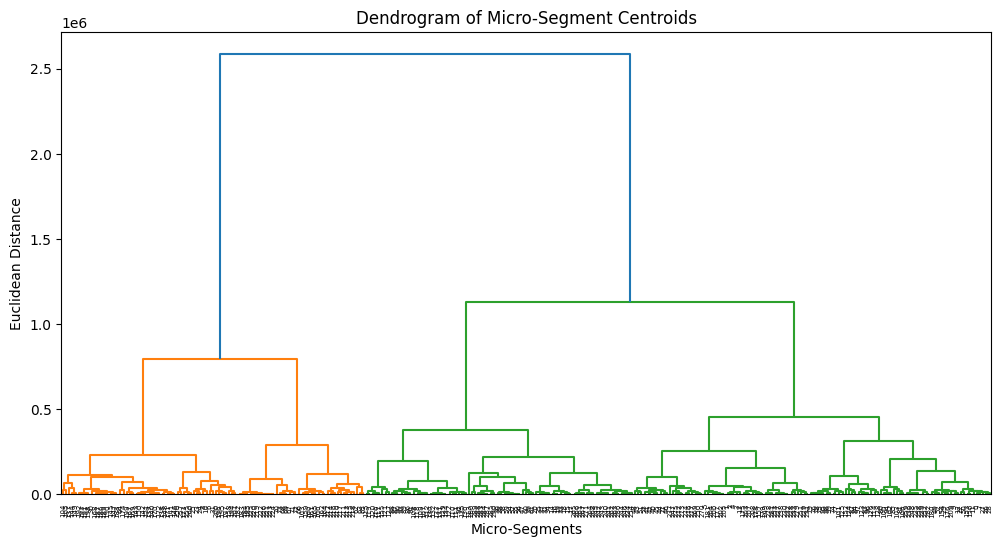

In [11]:
plt.figure(figsize=(12, 6))
plt.title('Dendrogram of Micro-Segment Centroids')

Z = linkage(df_centroids.values, method='ward')
dendro = dendrogram(Z)

plt.xlabel('Micro-Segments')
plt.ylabel('Euclidean Distance')
plt.show()


In [12]:
#HC WARD METHOD

n_final_clusters = 8

hclust_final = AgglomerativeClustering(
    linkage='ward',
    n_clusters=n_final_clusters
)

hclust_final_labels = hclust_final.fit_predict(df_centroids)
hclust_final_labels

# Add to centroids dataframe
df_centroids['merged_labels'] = hclust_final_labels
df_centroids

Income  \
Value_Label          Behavior_Label        Engagement_Label     Location_Label                 
seg_Core_Loyalists   seg_Active_Redeemers  seg_Active_Travelers Location__0     36467.166667   
                                                                Location__1     32556.773585   
                                                                Location__2     35434.261538   
                                                                Location__3     31775.600000   
                                                                Location__4     34258.803922   
...                                                                                      ...   
seg_Low_Value_Active seg_Holiday_travelers seg_Low_Engagement   Location__3      1778.509434   
                                                                Location__4      1750.267568   
                                                                Location__5      2584.676056   
                                                                Location__6      2913.000000   
                                                                Location__7         0.000000   

                                                                                Customer Lifetime Value  \
Value_Label          Behavior_Label        Engagement_Label     Location_Label                            
seg_Core_Loyalists   seg_Active_Redeemers  seg_Active_Travelers Location__0                10511.824167   
                                                                Location__1                 9712.113962   
                                                                Location__2                 9064.351231   
                                                                Location__3                10724.383500   
                                                                Location__4                 8233.630784   
...                                                                                                 ...   
seg_Low_Value_Active seg_Holiday_travelers seg_Low_Engagement   Location__3                 8100.739528   
                                                                Location__4                 7833.769703   
                                                                Location__5                 7371.415775   
                                                                Location__6                 7564.080000   
                                                                Location__7                 6689.503571   

                                                                                EnrollmentType  \
Value_Label          Behavior_Label        Engagement_Label     Location_Label                   
seg_Core_Loyalists   seg_Active_Redeemers  seg_Active_Travelers Location__0           0.083333   
                                                                Location__1           0.094340   
                                                                Location__2           0.200000   
                                                                Location__3           0.100000   
                                                                Location__4           0.078431   
...                                                                                        ...   
seg_Low_Value_Active seg_Holiday_travelers seg_Low_Engagement   Location__3           0.047170   
                                                                Location__4           0.045946   
                                                                Location__5           0.028169   
                                                                Location__6           0.000000   
                                                                Location__7           0.000000   

                                                                                rejoined_program  \
Value_Label          Behavior_Label        Engagement_Label     Locati

In [13]:
#KMEANS METHOD

kmeans_demo = KMeans(
    n_clusters=8,
    init='k-means++',
    n_init=20,
    random_state=42
)

demo_labels = kmeans_demo.fit_predict(df_centroids)
demo_labels

# Add to centroids dataframe
df_centroids['merged_labels'] = demo_labels
df_centroids

Income  \
Value_Label          Behavior_Label        Engagement_Label     Location_Label                 
seg_Core_Loyalists   seg_Active_Redeemers  seg_Active_Travelers Location__0     36467.166667   
                                                                Location__1     32556.773585   
                                                                Location__2     35434.261538   
                                                                Location__3     31775.600000   
                                                                Location__4     34258.803922   
...                                                                                      ...   
seg_Low_Value_Active seg_Holiday_travelers seg_Low_Engagement   Location__3      1778.509434   
                                                                Location__4      1750.267568   
                                                                Location__5      2584.676056   
                                                                Location__6      2913.000000   
                                                                Location__7         0.000000   

                                                                                Customer Lifetime Value  \
Value_Label          Behavior_Label        Engagement_Label     Location_Label                            
seg_Core_Loyalists   seg_Active_Redeemers  seg_Active_Travelers Location__0                10511.824167   
                                                                Location__1                 9712.113962   
                                                                Location__2                 9064.351231   
                                                                Location__3                10724.383500   
                                                                Location__4                 8233.630784   
...                                                                                                 ...   
seg_Low_Value_Active seg_Holiday_travelers seg_Low_Engagement   Location__3                 8100.739528   
                                                                Location__4                 7833.769703   
                                                                Location__5                 7371.415775   
                                                                Location__6                 7564.080000   
                                                                Location__7                 6689.503571   

                                                                                EnrollmentType  \
Value_Label          Behavior_Label        Engagement_Label     Location_Label                   
seg_Core_Loyalists   seg_Active_Redeemers  seg_Active_Travelers Location__0           0.083333   
                                                                Location__1           0.094340   
                                                                Location__2           0.200000   
                                                                Location__3           0.100000   
                                                                Location__4           0.078431   
...                                                                                        ...   
seg_Low_Value_Active seg_Holiday_travelers seg_Low_Engagement   Location__3           0.047170   
                                                                Location__4           0.045946   
                                                                Location__5           0.028169   
                                                                Location__6           0.000000   
                                                                Location__7           0.000000   

                                                                                rejoined_program  \
Value_Label          Behavior_Label        Engagement_Label     Locati

In [14]:
cluster_mapper = df_centroids['merged_labels'].to_dict()
cluster_mapper  

{('seg_Core_Loyalists',
  'seg_Active_Redeemers',
  'seg_Active_Travelers',
  'Location__0'): 0,
 ('seg_Core_Loyalists',
  'seg_Active_Redeemers',
  'seg_Active_Travelers',
  'Location__1'): 4,
 ('seg_Core_Loyalists',
  'seg_Active_Redeemers',
  'seg_Active_Travelers',
  'Location__2'): 4,
 ('seg_Core_Loyalists',
  'seg_Active_Redeemers',
  'seg_Active_Travelers',
  'Location__3'): 4,
 ('seg_Core_Loyalists',
  'seg_Active_Redeemers',
  'seg_Active_Travelers',
  'Location__4'): 4,
 ('seg_Core_Loyalists',
  'seg_Active_Redeemers',
  'seg_Active_Travelers',
  'Location__5'): 4,
 ('seg_Core_Loyalists',
  'seg_Active_Redeemers',
  'seg_Active_Travelers',
  'Location__6'): 0,
 ('seg_Core_Loyalists',
  'seg_Active_Redeemers',
  'seg_Active_Travelers',
  'Location__7'): 0,
 ('seg_Core_Loyalists',
  'seg_Active_Redeemers',
  'seg_Dormant_Travelers',
  'Location__0'): 0,
 ('seg_Core_Loyalists',
  'seg_Active_Redeemers',
  'seg_Dormant_Travelers',
  'Location__1'): 4,
 ('seg_Core_Loyalists',
  's

In [15]:
df_merged

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,TotalFlights,TotalDistance,...,seg_Dormant_Travelers,seg_Dormant_Travelers.1,seg_Low_Engagement,seg_Low_Engagement.1,seg_Non_Travelers,seg_Non_Travelers.1,Value_Label,Behavior_Label,Engagement_Label,Location_Label
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,0.0,0.0,...,0,0,0,0,1,1,seg_Inactive,seg_August_to_December_travelers,seg_Non_Travelers,Location__1
100012,34148.0,5780.18,0,0,0.0,0,2019,2,0.0,0.0,...,0,0,0,0,1,1,seg_Inactive,seg_August_to_December_travelers,seg_Non_Travelers,Location__4
100013,34148.0,5780.18,0,0,0.0,0,2017,9,0.0,0.0,...,0,0,0,0,1,1,seg_Inactive,seg_August_to_December_travelers,seg_Non_Travelers,Location__5
100014,34148.0,5780.18,0,0,0.0,0,2020,11,0.0,0.0,...,0,0,0,0,1,1,seg_Inactive,seg_August_to_December_travelers,seg_Non_Travelers,Location__3
100015,34148.0,5780.18,0,0,0.0,0,2020,4,0.0,0.0,...,0,0,0,0,1,1,seg_Inactive,seg_August_to_December_travelers,seg_Non_Travelers,Location__4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,0.0,0.0,...,0,0,0,0,1,1,seg_Inactive,seg_August_to_December_travelers,seg_Non_Travelers,Location__4
999996,34148.0,5780.18,0,0,0.0,0,2018,9,0.0,0.0,...,0,0,0,0,1,1,seg_Inactive,seg_August_to_December_travelers,seg_Non_Travelers,Location__1
999997,34148.0,5780.18,0,0,0.0,0,2020,1,0.0,0.0,...,0,0,0,0,1,1,seg_Inactive,seg_August_to_December_travelers,seg_Non_Travelers,Location__3


In [16]:
# Drop all columns starting with 'seg_' and the original label columns
cols_to_drop = [col for col in df_merged.columns if col.startswith('seg_')]

df_merged = df_merged.drop(columns=cols_to_drop)

In [17]:
df_merged

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,TotalFlights,TotalDistance,...,Location__2,Location__3,Location__4,Location__5,Location__6,Location__7,Value_Label,Behavior_Label,Engagement_Label,Location_Label
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,0.0,0.0,...,0,0,0,0,0,0,seg_Inactive,seg_August_to_December_travelers,seg_Non_Travelers,Location__1
100012,34148.0,5780.18,0,0,0.0,0,2019,2,0.0,0.0,...,0,0,1,0,0,0,seg_Inactive,seg_August_to_December_travelers,seg_Non_Travelers,Location__4
100013,34148.0,5780.18,0,0,0.0,0,2017,9,0.0,0.0,...,0,0,0,1,0,0,seg_Inactive,seg_August_to_December_travelers,seg_Non_Travelers,Location__5
100014,34148.0,5780.18,0,0,0.0,0,2020,11,0.0,0.0,...,0,1,0,0,0,0,seg_Inactive,seg_August_to_December_travelers,seg_Non_Travelers,Location__3
100015,34148.0,5780.18,0,0,0.0,0,2020,4,0.0,0.0,...,0,0,1,0,0,0,seg_Inactive,seg_August_to_December_travelers,seg_Non_Travelers,Location__4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,0.0,0.0,...,0,0,1,0,0,0,seg_Inactive,seg_August_to_December_travelers,seg_Non_Travelers,Location__4
999996,34148.0,5780.18,0,0,0.0,0,2018,9,0.0,0.0,...,0,0,0,0,0,0,seg_Inactive,seg_August_to_December_travelers,seg_Non_Travelers,Location__1
999997,34148.0,5780.18,0,0,0.0,0,2020,1,0.0,0.0,...,0,1,0,0,0,0,seg_Inactive,seg_August_to_December_travelers,seg_Non_Travelers,Location__3


In [18]:
df_merged['merged_labels'] = df_merged.apply(
    lambda row: cluster_mapper[(row['Value_Label'], row['Behavior_Label'], row['Engagement_Label'], row['Location_Label'])],
    axis=1
)
df_merged

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,TotalFlights,TotalDistance,...,Location__3,Location__4,Location__5,Location__6,Location__7,Value_Label,Behavior_Label,Engagement_Label,Location_Label,merged_labels
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,0.0,0.0,...,0,0,0,0,0,seg_Inactive,seg_August_to_December_travelers,seg_Non_Travelers,Location__1,2
100012,34148.0,5780.18,0,0,0.0,0,2019,2,0.0,0.0,...,0,1,0,0,0,seg_Inactive,seg_August_to_December_travelers,seg_Non_Travelers,Location__4,2
100013,34148.0,5780.18,0,0,0.0,0,2017,9,0.0,0.0,...,0,0,1,0,0,seg_Inactive,seg_August_to_December_travelers,seg_Non_Travelers,Location__5,2
100014,34148.0,5780.18,0,0,0.0,0,2020,11,0.0,0.0,...,1,0,0,0,0,seg_Inactive,seg_August_to_December_travelers,seg_Non_Travelers,Location__3,2
100015,34148.0,5780.18,0,0,0.0,0,2020,4,0.0,0.0,...,0,1,0,0,0,seg_Inactive,seg_August_to_December_travelers,seg_Non_Travelers,Location__4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,0.0,0.0,...,0,1,0,0,0,seg_Inactive,seg_August_to_December_travelers,seg_Non_Travelers,Location__4,2
999996,34148.0,5780.18,0,0,0.0,0,2018,9,0.0,0.0,...,0,0,0,0,0,seg_Inactive,seg_August_to_December_travelers,seg_Non_Travelers,Location__1,2
999997,34148.0,5780.18,0,0,0.0,0,2020,1,0.0,0.0,...,1,0,0,0,0,seg_Inactive,seg_August_to_December_travelers,seg_Non_Travelers,Location__3,2


In [19]:
print(df_merged['merged_labels'].value_counts().sort_index())

merged_labels
0     314
1    6380
2    1657
3    3495
4    1050
5    3110
6     419
7     290
Name: count, dtype: int64


In [20]:
r2_merged = get_rsq(df_merged, metric_features, 'merged_labels')
print(f"\nMerged clustering R²: {r2_merged:.4f}")


Merged clustering R²: 0.7776


# <span style="color:#0097b2">4. Profiling & Feature Importance</span>
[Back to TOC](#toc)

In [21]:
# 1. Calculate R2 for ALL variables (Active + Passive)
numeric_cols = df_merged.select_dtypes(include=[np.number]).columns.tolist()

# Remove the cluster labels themselves
numeric_cols = [c for c in numeric_cols if c not in ['Final_Solution_Label', 'Location_cluster', 'EnrollmentType']]

def get_r2_scores(df, cluster_col, features):
    sst_total = df[features].var() * (len(df) - 1)
    r2_scores = {}
    for feature in features:
        sst = sst_total[feature]
        if sst == 0: continue 
        ssw = 0
        for cluster in df[cluster_col].unique():
            cluster_data = df[df[cluster_col] == cluster][feature]
            ssw += cluster_data.var() * (len(cluster_data) - 1)
        r2_scores[feature] = (sst - ssw) / sst
    return pd.Series(r2_scores).sort_values(ascending=False)

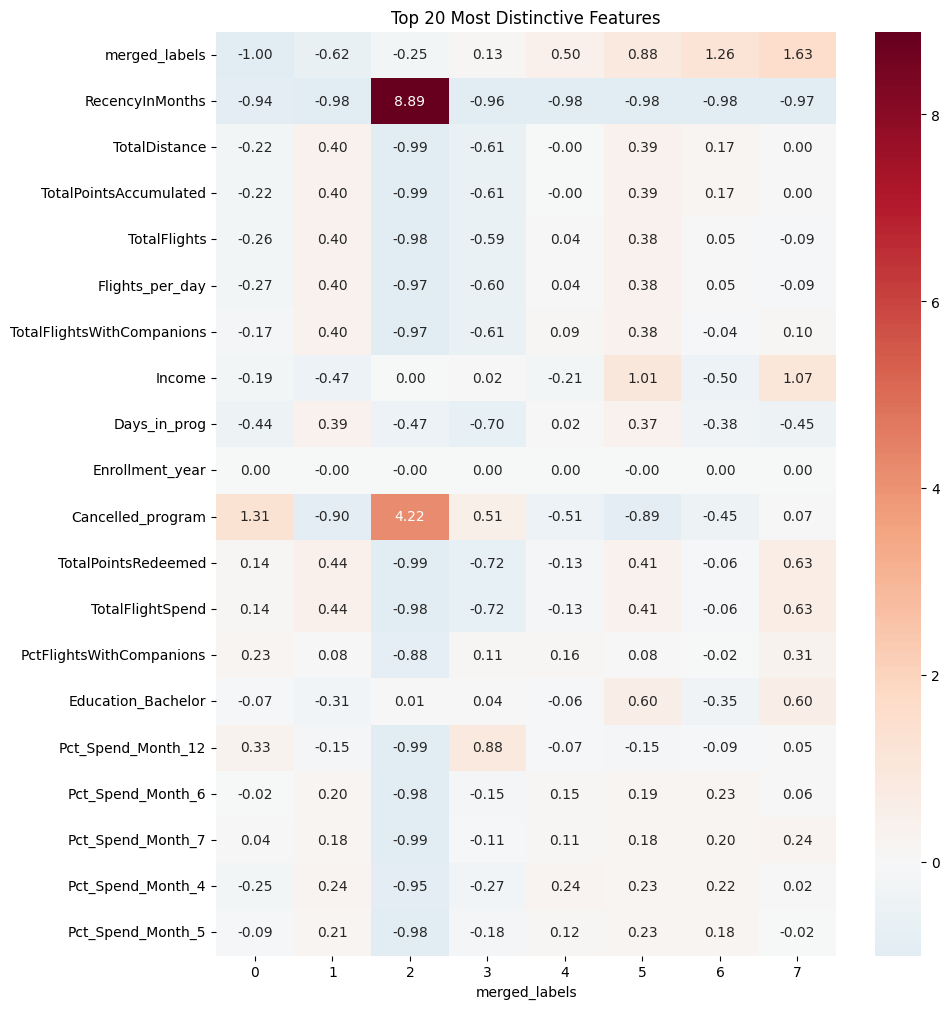

In [22]:
# 2. Get Top 20 Differentiating Features
top_features = get_r2_scores(df_merged, 'merged_labels', numeric_cols).head(20).index.tolist()

# 3. Plot Heatmap ONLY for these Top 20
cluster_means = df_merged.groupby('merged_labels')[top_features].mean()
global_means = df_merged[top_features].mean()
relative_imp = (cluster_means / global_means) - 1

plt.figure(figsize=(10, 12))
sns.heatmap(data=relative_imp.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Top 20 Most Distinctive Features')
plt.show()

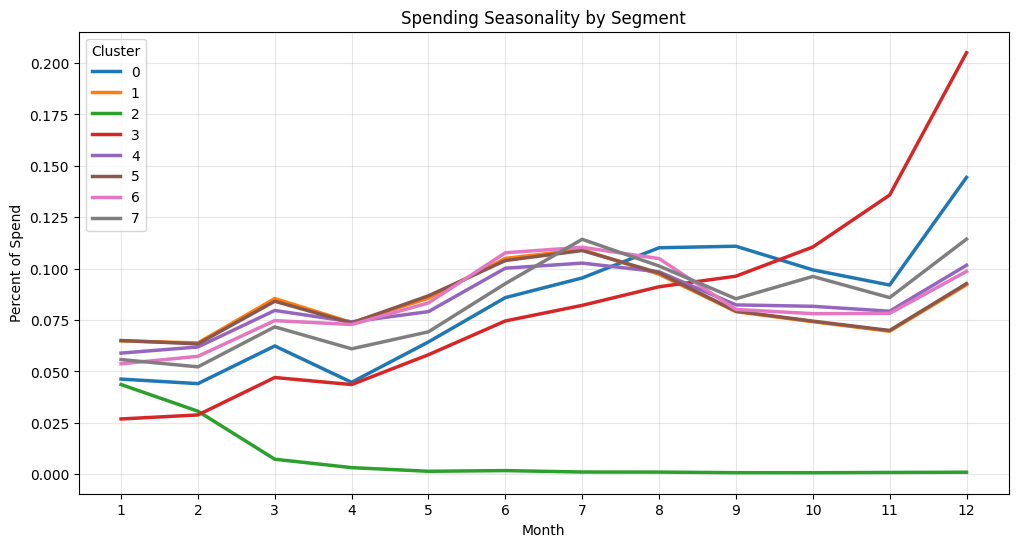

In [23]:
seasonality_cols = [f'Pct_Spend_Month_{i}' for i in range(1, 13)]

# Group by Cluster and get the mean of monthly spend
monthly_profile = df_merged.groupby('merged_labels')[seasonality_cols].mean()

monthly_profile.columns = range(1, 13)

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_profile.T, dashes=False, palette='tab10', linewidth=2.5)

plt.title('Spending Seasonality by Segment')
plt.xlabel('Month')
plt.ylabel('Percent of Spend')
plt.xticks(range(1, 13))
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
cluster_profile = groupby_mean(df_merged, 'merged_labels', n_features=80)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(cluster_profile)

merged_labels                               0              1             2  \
Income                           30500.363057   19856.784169  37853.535305   
Customer Lifetime Value          12492.798694    8057.420075   8276.063844   
EnrollmentType                       0.038217       0.034483      0.025347   
rejoined_program                     0.019108       0.000000      0.013277   
Days_in_prog                       614.633758    1519.666928    582.060954   
Cancelled_program                    0.283439       0.012539      0.639710   
Enrollment_year                   2019.493631    2017.331661   2017.841883   
Enrollment_month                     6.573248       6.528683      7.222088   
TotalFlights                       105.943949     201.938574      2.222088   
TotalDistance                   223864.460191  403150.223683   4105.496319   
TotalPointsAccumulated           22382.083917   40307.364187    410.469427   
TotalPointsRedeemed               9724.257006   12316.121301    